In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns


import time
import math
import random
import re
import os
import sys


from utils.util import find_files_with_extension
from utils.util import  get_dataframe_from_filepath,calculate_statistics, extract_unique_mbps_and_ms
from utils.util import remove_outliers_iqr, comma_format, create_directory_if_not_exists,print_rtt_stats,save_rtt_stats,return_rtt_stats
from utils.udp_util import extract_udp_prague_to_dataframe

In [13]:
# Load data
mainpth="../data/udp_data_2025-04-11"
mainpth="../data/udp_data_2025-04-27"
mainpth="../data/udp_data_2025-04-28"


graph_directory = os.path.join(mainpth, "Graphs")
create_directory_if_not_exists(graph_directory)

stats_directory = os.path.join(mainpth, "Stats")
create_directory_if_not_exists(stats_directory)


folderpaths = [mainpth+'/server_data', mainpth+'/client1_data', mainpth+'/client2_data']
filenames, filepaths, filedict = find_files_with_extension(folderpaths, '')


# Call the function and print unique combinations
unique_combinations = extract_unique_mbps_and_ms(folderpaths)
print("Unique Mbps and ms Combinations:")
for mbps, ms in sorted(unique_combinations):
    print(f'{mbps} Mbps, {ms} ms')




Directory already exists: ../data/udp_data_2025-04-28\Graphs
Directory already exists: ../data/udp_data_2025-04-28\Stats
Unique Mbps and ms Combinations:
200 Mbps, 0 ms
200 Mbps, 10 ms
200 Mbps, 20 ms
200 Mbps, 5 ms
250 Mbps, 0 ms
250 Mbps, 10 ms
250 Mbps, 20 ms
250 Mbps, 5 ms


In [14]:
unique_scenarios_dict_v2 = {}
for mbps, ms in unique_combinations:
    scenario_search = f"{mbps}Mbps_{ms}ms"
    for index in range(len(filenames)):
        if scenario_search in filenames[index]:
            print(f"Found {scenario_search} in {filenames[index]}")
            if scenario_search in unique_scenarios_dict_v2:
                unique_scenarios_dict_v2[scenario_search].append(filedict[filenames[index]])
            else:
                unique_scenarios_dict_v2[scenario_search]=[filedict[filenames[index]]]
            


Found 200Mbps_10ms in 1_dualpi2_200Mbps_10ms_ecn_udp_dsthost.em1.pcap
Found 200Mbps_10ms in 1_dualpi2_200Mbps_10ms_ecn_udp_dsthost.siftr.log
Found 200Mbps_10ms in 2_dualpi2_200Mbps_10ms_ecn_udp_dsthost.em1.pcap
Found 200Mbps_10ms in 2_dualpi2_200Mbps_10ms_ecn_udp_dsthost.siftr.log
Found 200Mbps_10ms in udp_prague_receiver_1_dualpi2_200Mbps_10ms_ecn_udp.txt
Found 200Mbps_10ms in udp_prague_receiver_2_dualpi2_200Mbps_10ms_ecn_udp.txt
Found 200Mbps_10ms in udp_prague_sender_1_dualpi2_200Mbps_10ms_ecn_udp.txt
Found 200Mbps_10ms in udp_prague_sender_2_dualpi2_200Mbps_10ms_ecn_udp.txt
Found 200Mbps_10ms in 1_dualpi2_200Mbps_10ms_ecn_udp_cubic_src1.em1.pcap
Found 200Mbps_10ms in 1_dualpi2_200Mbps_10ms_ecn_udp_cubic_src1.siftr.log
Found 200Mbps_10ms in 2_dualpi2_200Mbps_10ms_ecn_udp_cubic_src1.em1.pcap
Found 200Mbps_10ms in 2_dualpi2_200Mbps_10ms_ecn_udp_cubic_src1.siftr.log
Found 200Mbps_10ms in 1_dualpi2_200Mbps_10ms_ecn_udp_dctcp_src2.em1.pcap
Found 200Mbps_10ms in 1_dualpi2_200Mbps_10ms_ec

In [15]:
# unique_scenarios_dict_v2['100Mbps_10ms']

In [16]:
from utils.plotter import  plot_siftr_graph

In [17]:
for scenario in unique_scenarios_dict_v2.keys():
    index = "1_dualpi2"

    search_list = ["1_dualpi2", "log", "txt"]

    print()
    print("Start New Scenario")
    # print(scenario)
    # print(unique_scenarios_dict_v2[scenario])

    print("Scenario", scenario)
    

    my_list = unique_scenarios_dict_v2[scenario]


    for i, item in enumerate(my_list, start=0):
        print(f"{i}. {item}")


    print(unique_scenarios_dict_v2[scenario])
    print("utf", unique_scenarios_dict_v2[scenario][4])
    print("ttf", unique_scenarios_dict_v2[scenario][13])



Start New Scenario
Scenario 200Mbps_10ms
0. ../data/udp_data_2025-04-28/server_data\1_dualpi2_200Mbps_10ms_ecn_udp_dsthost.em1.pcap
1. ../data/udp_data_2025-04-28/server_data\1_dualpi2_200Mbps_10ms_ecn_udp_dsthost.siftr.log
2. ../data/udp_data_2025-04-28/server_data\2_dualpi2_200Mbps_10ms_ecn_udp_dsthost.em1.pcap
3. ../data/udp_data_2025-04-28/server_data\2_dualpi2_200Mbps_10ms_ecn_udp_dsthost.siftr.log
4. ../data/udp_data_2025-04-28/server_data\udp_prague_receiver_1_dualpi2_200Mbps_10ms_ecn_udp.txt
5. ../data/udp_data_2025-04-28/server_data\udp_prague_receiver_2_dualpi2_200Mbps_10ms_ecn_udp.txt
6. ../data/udp_data_2025-04-28/server_data\udp_prague_sender_1_dualpi2_200Mbps_10ms_ecn_udp.txt
7. ../data/udp_data_2025-04-28/server_data\udp_prague_sender_2_dualpi2_200Mbps_10ms_ecn_udp.txt
8. ../data/udp_data_2025-04-28/client1_data\1_dualpi2_200Mbps_10ms_ecn_udp_cubic_src1.em1.pcap
9. ../data/udp_data_2025-04-28/client1_data\1_dualpi2_200Mbps_10ms_ecn_udp_cubic_src1.siftr.log
10. ../data/u


Start New Scenario
Scenario 200Mbps_10ms
['../data/udp_data_2025-04-28/server_data\\1_dualpi2_200Mbps_10ms_ecn_udp_dsthost.em1.pcap', '../data/udp_data_2025-04-28/server_data\\1_dualpi2_200Mbps_10ms_ecn_udp_dsthost.siftr.log', '../data/udp_data_2025-04-28/server_data\\2_dualpi2_200Mbps_10ms_ecn_udp_dsthost.em1.pcap', '../data/udp_data_2025-04-28/server_data\\2_dualpi2_200Mbps_10ms_ecn_udp_dsthost.siftr.log', '../data/udp_data_2025-04-28/server_data\\udp_prague_receiver_1_dualpi2_200Mbps_10ms_ecn_udp.txt', '../data/udp_data_2025-04-28/server_data\\udp_prague_receiver_2_dualpi2_200Mbps_10ms_ecn_udp.txt', '../data/udp_data_2025-04-28/server_data\\udp_prague_sender_1_dualpi2_200Mbps_10ms_ecn_udp.txt', '../data/udp_data_2025-04-28/server_data\\udp_prague_sender_2_dualpi2_200Mbps_10ms_ecn_udp.txt', '../data/udp_data_2025-04-28/client1_data\\1_dualpi2_200Mbps_10ms_ecn_udp_cubic_src1.em1.pcap', '../data/udp_data_2025-04-28/client1_data\\1_dualpi2_200Mbps_10ms_ecn_udp_cubic_src1.siftr.log', '.

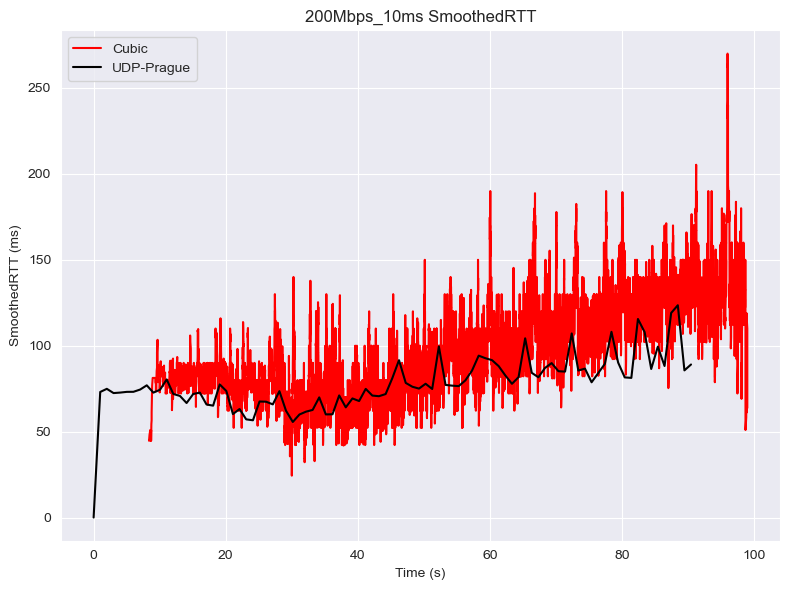


Start New Scenario
Scenario 250Mbps_0ms
['../data/udp_data_2025-04-28/server_data\\1_dualpi2_250Mbps_0ms_ecn_udp_dsthost.em1.pcap', '../data/udp_data_2025-04-28/server_data\\1_dualpi2_250Mbps_0ms_ecn_udp_dsthost.siftr.log', '../data/udp_data_2025-04-28/server_data\\2_dualpi2_250Mbps_0ms_ecn_udp_dsthost.em1.pcap', '../data/udp_data_2025-04-28/server_data\\2_dualpi2_250Mbps_0ms_ecn_udp_dsthost.siftr.log', '../data/udp_data_2025-04-28/server_data\\udp_prague_receiver_1_dualpi2_250Mbps_0ms_ecn_udp.txt', '../data/udp_data_2025-04-28/server_data\\udp_prague_receiver_2_dualpi2_250Mbps_0ms_ecn_udp.txt', '../data/udp_data_2025-04-28/server_data\\udp_prague_sender_1_dualpi2_250Mbps_0ms_ecn_udp.txt', '../data/udp_data_2025-04-28/server_data\\udp_prague_sender_2_dualpi2_250Mbps_0ms_ecn_udp.txt', '../data/udp_data_2025-04-28/client1_data\\1_dualpi2_250Mbps_0ms_ecn_udp_cubic_src1.em1.pcap', '../data/udp_data_2025-04-28/client1_data\\1_dualpi2_250Mbps_0ms_ecn_udp_cubic_src1.siftr.log', '../data/udp_

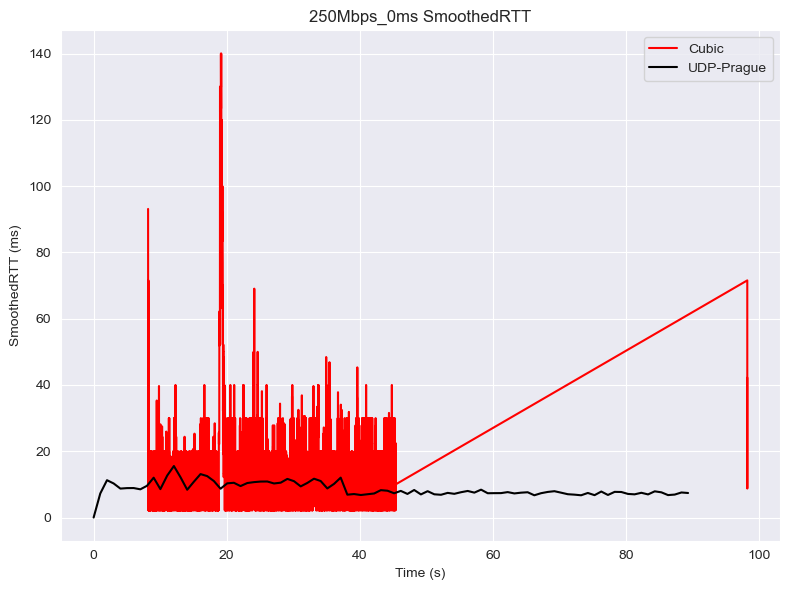


Start New Scenario
Scenario 200Mbps_20ms
['../data/udp_data_2025-04-28/server_data\\1_dualpi2_200Mbps_20ms_ecn_udp_dsthost.em1.pcap', '../data/udp_data_2025-04-28/server_data\\1_dualpi2_200Mbps_20ms_ecn_udp_dsthost.siftr.log', '../data/udp_data_2025-04-28/server_data\\2_dualpi2_200Mbps_20ms_ecn_udp_dsthost.em1.pcap', '../data/udp_data_2025-04-28/server_data\\2_dualpi2_200Mbps_20ms_ecn_udp_dsthost.siftr.log', '../data/udp_data_2025-04-28/server_data\\udp_prague_receiver_1_dualpi2_200Mbps_20ms_ecn_udp.txt', '../data/udp_data_2025-04-28/server_data\\udp_prague_receiver_2_dualpi2_200Mbps_20ms_ecn_udp.txt', '../data/udp_data_2025-04-28/server_data\\udp_prague_sender_1_dualpi2_200Mbps_20ms_ecn_udp.txt', '../data/udp_data_2025-04-28/server_data\\udp_prague_sender_2_dualpi2_200Mbps_20ms_ecn_udp.txt', '../data/udp_data_2025-04-28/client1_data\\1_dualpi2_200Mbps_20ms_ecn_udp_cubic_src1.em1.pcap', '../data/udp_data_2025-04-28/client1_data\\1_dualpi2_200Mbps_20ms_ecn_udp_cubic_src1.siftr.log', '.

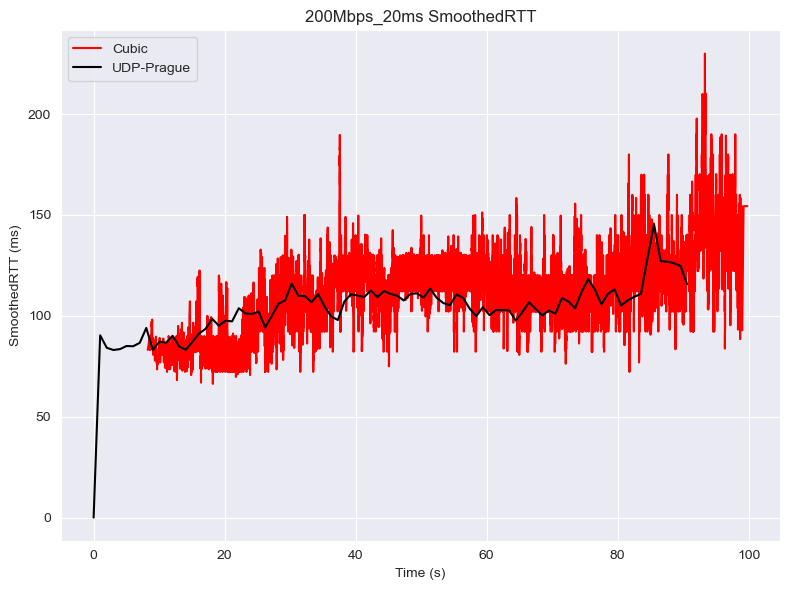


Start New Scenario
Scenario 250Mbps_5ms
['../data/udp_data_2025-04-28/server_data\\1_dualpi2_250Mbps_5ms_ecn_udp_dsthost.em1.pcap', '../data/udp_data_2025-04-28/server_data\\1_dualpi2_250Mbps_5ms_ecn_udp_dsthost.siftr.log', '../data/udp_data_2025-04-28/server_data\\2_dualpi2_250Mbps_5ms_ecn_udp_dsthost.em1.pcap', '../data/udp_data_2025-04-28/server_data\\2_dualpi2_250Mbps_5ms_ecn_udp_dsthost.siftr.log', '../data/udp_data_2025-04-28/server_data\\udp_prague_receiver_1_dualpi2_250Mbps_5ms_ecn_udp.txt', '../data/udp_data_2025-04-28/server_data\\udp_prague_receiver_2_dualpi2_250Mbps_5ms_ecn_udp.txt', '../data/udp_data_2025-04-28/server_data\\udp_prague_sender_1_dualpi2_250Mbps_5ms_ecn_udp.txt', '../data/udp_data_2025-04-28/server_data\\udp_prague_sender_2_dualpi2_250Mbps_5ms_ecn_udp.txt', '../data/udp_data_2025-04-28/client1_data\\1_dualpi2_250Mbps_5ms_ecn_udp_cubic_src1.em1.pcap', '../data/udp_data_2025-04-28/client1_data\\1_dualpi2_250Mbps_5ms_ecn_udp_cubic_src1.siftr.log', '../data/udp_

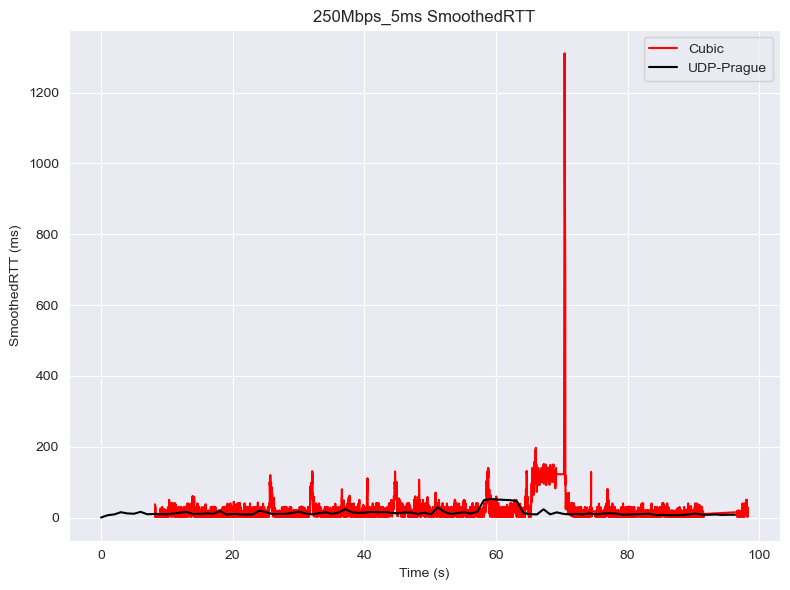


Start New Scenario
Scenario 200Mbps_0ms
['../data/udp_data_2025-04-28/server_data\\1_dualpi2_200Mbps_0ms_ecn_udp_dsthost.em1.pcap', '../data/udp_data_2025-04-28/server_data\\1_dualpi2_200Mbps_0ms_ecn_udp_dsthost.siftr.log', '../data/udp_data_2025-04-28/server_data\\2_dualpi2_200Mbps_0ms_ecn_udp_dsthost.em1.pcap', '../data/udp_data_2025-04-28/server_data\\2_dualpi2_200Mbps_0ms_ecn_udp_dsthost.siftr.log', '../data/udp_data_2025-04-28/server_data\\udp_prague_receiver_1_dualpi2_200Mbps_0ms_ecn_udp.txt', '../data/udp_data_2025-04-28/server_data\\udp_prague_receiver_2_dualpi2_200Mbps_0ms_ecn_udp.txt', '../data/udp_data_2025-04-28/server_data\\udp_prague_sender_1_dualpi2_200Mbps_0ms_ecn_udp.txt', '../data/udp_data_2025-04-28/server_data\\udp_prague_sender_2_dualpi2_200Mbps_0ms_ecn_udp.txt', '../data/udp_data_2025-04-28/client1_data\\1_dualpi2_200Mbps_0ms_ecn_udp_cubic_src1.em1.pcap', '../data/udp_data_2025-04-28/client1_data\\1_dualpi2_200Mbps_0ms_ecn_udp_cubic_src1.siftr.log', '../data/udp_

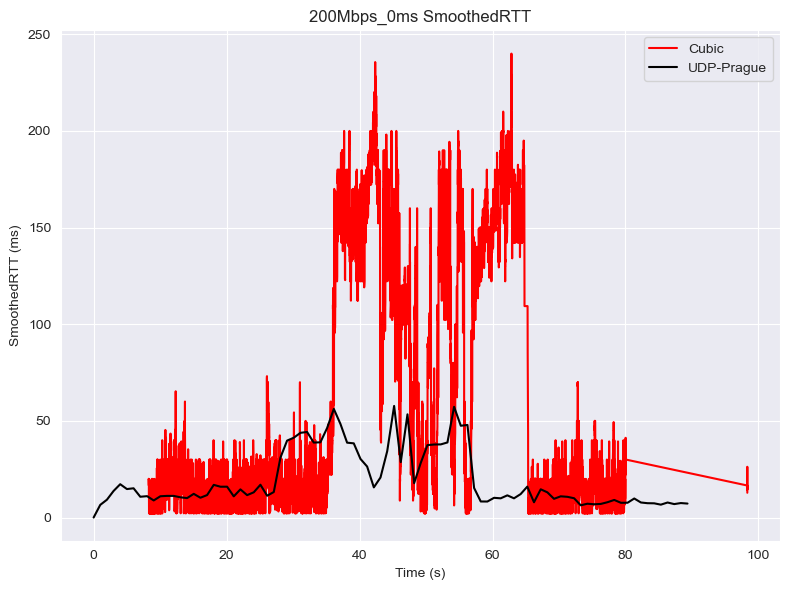


Start New Scenario
Scenario 250Mbps_10ms
['../data/udp_data_2025-04-28/server_data\\1_dualpi2_250Mbps_10ms_ecn_udp_dsthost.em1.pcap', '../data/udp_data_2025-04-28/server_data\\1_dualpi2_250Mbps_10ms_ecn_udp_dsthost.siftr.log', '../data/udp_data_2025-04-28/server_data\\2_dualpi2_250Mbps_10ms_ecn_udp_dsthost.em1.pcap', '../data/udp_data_2025-04-28/server_data\\2_dualpi2_250Mbps_10ms_ecn_udp_dsthost.siftr.log', '../data/udp_data_2025-04-28/server_data\\udp_prague_receiver_1_dualpi2_250Mbps_10ms_ecn_udp.txt', '../data/udp_data_2025-04-28/server_data\\udp_prague_receiver_2_dualpi2_250Mbps_10ms_ecn_udp.txt', '../data/udp_data_2025-04-28/server_data\\udp_prague_sender_1_dualpi2_250Mbps_10ms_ecn_udp.txt', '../data/udp_data_2025-04-28/server_data\\udp_prague_sender_2_dualpi2_250Mbps_10ms_ecn_udp.txt', '../data/udp_data_2025-04-28/client1_data\\1_dualpi2_250Mbps_10ms_ecn_udp_cubic_src1.em1.pcap', '../data/udp_data_2025-04-28/client1_data\\1_dualpi2_250Mbps_10ms_ecn_udp_cubic_src1.siftr.log', '.

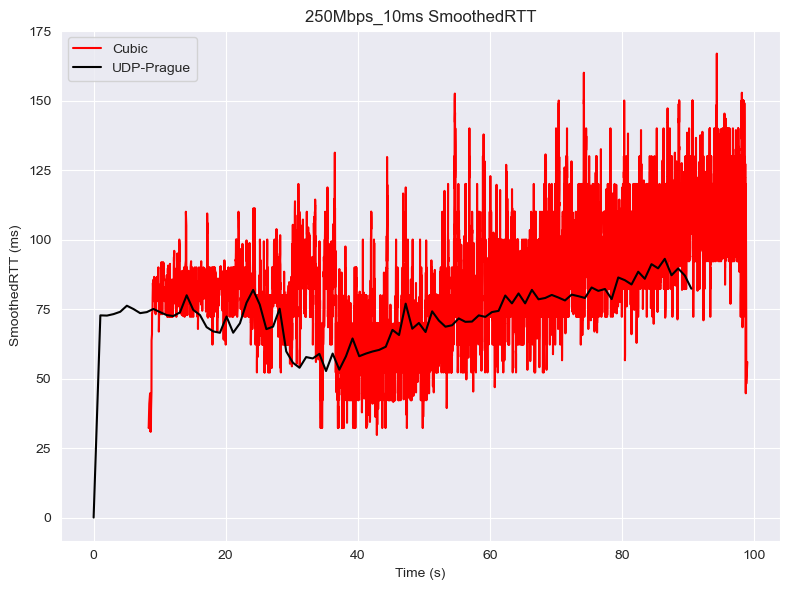


Start New Scenario
Scenario 250Mbps_20ms
['../data/udp_data_2025-04-28/server_data\\1_dualpi2_250Mbps_20ms_ecn_udp_dsthost.em1.pcap', '../data/udp_data_2025-04-28/server_data\\1_dualpi2_250Mbps_20ms_ecn_udp_dsthost.siftr.log', '../data/udp_data_2025-04-28/server_data\\2_dualpi2_250Mbps_20ms_ecn_udp_dsthost.em1.pcap', '../data/udp_data_2025-04-28/server_data\\2_dualpi2_250Mbps_20ms_ecn_udp_dsthost.siftr.log', '../data/udp_data_2025-04-28/server_data\\udp_prague_receiver_1_dualpi2_250Mbps_20ms_ecn_udp.txt', '../data/udp_data_2025-04-28/server_data\\udp_prague_receiver_2_dualpi2_250Mbps_20ms_ecn_udp.txt', '../data/udp_data_2025-04-28/server_data\\udp_prague_sender_1_dualpi2_250Mbps_20ms_ecn_udp.txt', '../data/udp_data_2025-04-28/server_data\\udp_prague_sender_2_dualpi2_250Mbps_20ms_ecn_udp.txt', '../data/udp_data_2025-04-28/client1_data\\1_dualpi2_250Mbps_20ms_ecn_udp_cubic_src1.em1.pcap', '../data/udp_data_2025-04-28/client1_data\\1_dualpi2_250Mbps_20ms_ecn_udp_cubic_src1.siftr.log', '.

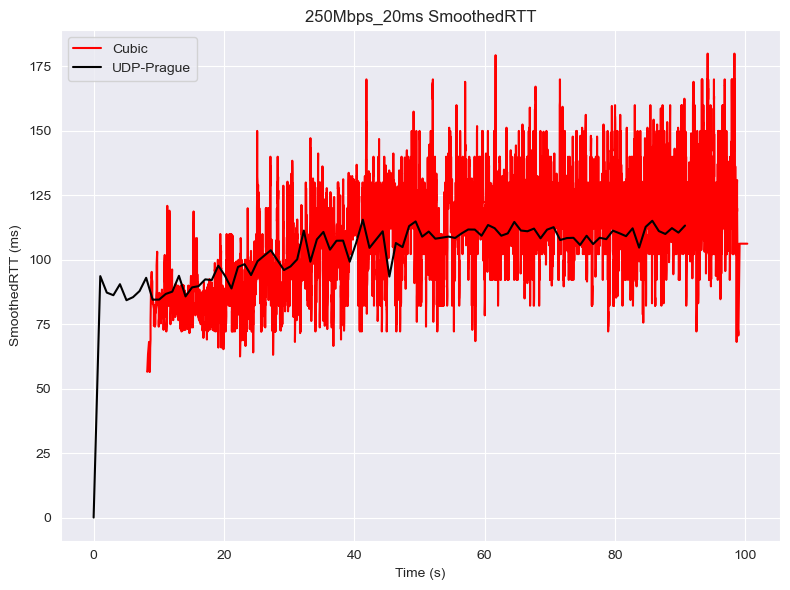


Start New Scenario
Scenario 200Mbps_5ms
['../data/udp_data_2025-04-28/server_data\\1_dualpi2_200Mbps_5ms_ecn_udp_dsthost.em1.pcap', '../data/udp_data_2025-04-28/server_data\\1_dualpi2_200Mbps_5ms_ecn_udp_dsthost.siftr.log', '../data/udp_data_2025-04-28/server_data\\2_dualpi2_200Mbps_5ms_ecn_udp_dsthost.em1.pcap', '../data/udp_data_2025-04-28/server_data\\2_dualpi2_200Mbps_5ms_ecn_udp_dsthost.siftr.log', '../data/udp_data_2025-04-28/server_data\\udp_prague_receiver_1_dualpi2_200Mbps_5ms_ecn_udp.txt', '../data/udp_data_2025-04-28/server_data\\udp_prague_receiver_2_dualpi2_200Mbps_5ms_ecn_udp.txt', '../data/udp_data_2025-04-28/server_data\\udp_prague_sender_1_dualpi2_200Mbps_5ms_ecn_udp.txt', '../data/udp_data_2025-04-28/server_data\\udp_prague_sender_2_dualpi2_200Mbps_5ms_ecn_udp.txt', '../data/udp_data_2025-04-28/client1_data\\1_dualpi2_200Mbps_5ms_ecn_udp_cubic_src1.em1.pcap', '../data/udp_data_2025-04-28/client1_data\\1_dualpi2_200Mbps_5ms_ecn_udp_cubic_src1.siftr.log', '../data/udp_

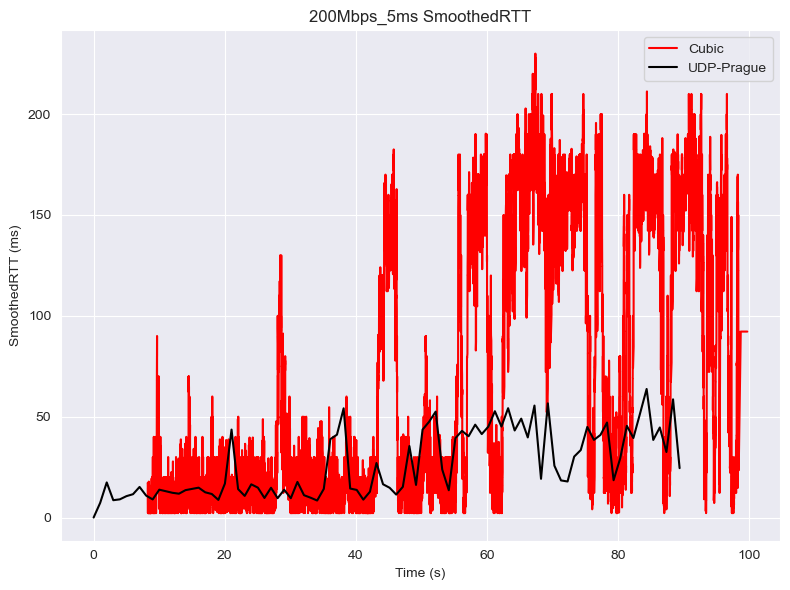

In [18]:
for scenario in unique_scenarios_dict_v2.keys():
    index = "1_dualpi2"

    search_list = ["1_dualpi2", "log", "txt"]

    print()
    print("Start New Scenario")
    # print(scenario)
    # print(unique_scenarios_dict_v2[scenario])

    print("Scenario", scenario)
    print(unique_scenarios_dict_v2[scenario])

    print("utf", unique_scenarios_dict_v2[scenario][4])
    print("ttf", unique_scenarios_dict_v2[scenario][13])

    


    udp_traffic = unique_scenarios_dict_v2[scenario][4]
    utf = extract_udp_prague_to_dataframe(udp_traffic)

    tcp_traffic = unique_scenarios_dict_v2[scenario][13]
    ttf = get_dataframe_from_filepath(tcp_traffic)
    ttf = ttf[ttf['ForeignPort'] == "5102"]

    utf.rename(columns={'RTT_ms': 'SmoothedRTT'}, inplace=True)



        # Define paths
    paths = {
        "Cubic": ttf,
        "UDP-Prague": utf
    }

    plot_siftr_graph(paths=paths,
                    ycolumn="SmoothedRTT",
                    title=f"{scenario} SmoothedRTT",
                    xlabel="Time (s)",
                    ylabel="SmoothedRTT (ms)",
                    filename=f'{scenario}_SmoothedRTT',
                    graph_directory=graph_directory,
    )


    # # Extract the second part of the float time (i.e., the integer part as seconds)
    # ttf['Second'] = ttf['Time'].apply(lambda x: int(x))

    # # Group by 'Second' and calculate the median for the 'RTT' column
    # ttf_grouped = ttf.groupby('Second')['SmoothedRTT'].median().reset_index()


    #     # Extract the second part of the float time (i.e., the integer part as seconds)
    # utf['Second'] = utf['Time'].apply(lambda x: int(x))

    # # Group by 'Second' and calculate the median for the 'RTT' column
    # utf_grouped = utf.groupby('Second')['RTT_ms'].median().reset_index()

    # # ttf_grouped = ttf.groupby('Time')['SmoothedRTT'].median().reset_index()
    # # utf_grouped = utf.groupby('Time')['RTT_ms'].median().reset_index()

    # Plotting both
    # plt.figure(figsize=(12, 6))
    # plt.plot(ttf['Time'], ttf['SmoothedRTT'], label='TCP NewReno', marker='x',color='red')
    # plt.plot(utf['Time'], utf['RTT_ms'], label='UDP-Prague', marker='x',color='black')
    # plt.xlabel('Time (s)')
    # plt.ylabel('RTT (ms)')
    # plt.title('TCP NewReno vs UDP-Prague RTT Comparison')
    # plt.legend()
    # plt.grid(True)
    # plt.tight_layout()
    # plt.show()

    # print("utf")


In [19]:
ttf['Time'].head(40)

72     8.256305
73     8.256774
75     8.257914
76     8.258031
79     8.259945
80     8.260061
82     8.261939
84     8.262162
85     8.262204
86     8.262253
87     8.262287
88     8.262327
89     8.262372
90     8.262404
91     8.262441
92     8.262472
94     8.262900
95     8.262966
97     8.263014
98     8.263054
100    8.263097
101    8.263129
103    8.263213
104    8.263255
106    8.263309
107    8.263340
109    8.263591
110    8.263642
111    8.263676
113    8.263719
114    8.263760
116    8.263802
117    8.263841
119    8.263889
120    8.263921
122    8.263970
123    8.264001
125    8.264166
126    8.264208
127    8.264240
Name: Time, dtype: float64

In [20]:
ttf

,Direction,Time,LocalIP,LocalPort,ForeignIP,ForeignPort,SlowStartThreshold,CongestionWindow,BandwidthControlledWindow,SendingWindow,...,TCPFlags,RetransmissionTimeout,SocketSendBufferSize,SocketSendBufferBytes,SocketReceiveBufferSize,SocketReceiveBufferBytes,UnacknowledgedBytes,ReassemblyQueue,Flowid,Flowtype
72,o,8.256305,192.168.1.3,13142,192.168.3.2,5102,3000,14480,290,65535,...,993,260000,33580,0,65700,0,0,0,1396187481,63
73,o,8.256774,192.168.1.3,13142,192.168.3.2,5102,3000,14480,290,65535,...,996,260000,33580,37,65700,0,0,0,1396187481,63
75,o,8.257914,192.168.1.3,13142,192.168.3.2,5102,3000,14480,1314,65728,...,996,260000,33580,4,65700,0,0,0,1396187481,63
76,o,8.258031,192.168.1.3,13142,192.168.3.2,5102,3000,14480,1314,65728,...,33764,260000,33580,128,65700,0,4,0,1396187481,63
79,o,8.259945,192.168.1.3,13142,192.168.3.2,5102,3000,14480,290,65535,...,993,260000,33580,0,65700,0,0,0,1396187481,63
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
841945,o,98.407667,192.168.1.3,13142,192.168.3.2,5102,10860,14480,1314,65728,...,33764,310000,33580,1,65700,0,1,0,1396187481,63
841948,o,98.408186,192.168.1.3,13142,192.168.3.2,5102,10860,14480,1314,65728,...,67109879,300000,33580,0,65700,0,0,0,1396187481,63
841960,o,98.719213,192.168.1.3,13142,192.168.3.2,5102,28960,1448,354,1683840,...,1140859889,400000,1860396,289600,65700,0,289601,0,1396187481,63
841961,o,99.118964,192.168.1.3,13142,192.168.3.2,5102,2896,1448,354,1683840,...,1140851697,600000,1860396,289600,65700,0,289601,0,1396187481,63


In [21]:
utf

,Time,Rcvd_Mbps,Sent_Mbps,SmoothedRTT,Mark_pct,Mark_Marked,Mark_Total,Lost_pct,Lost_Lost,Lost_Total
0,0.00,0.001,0.000,0.000,0.0,0,1,0.00,0,1
1,1.00,3.981,0.063,7.271,0.0,0,357,0.00,0,357
2,2.00,6.598,0.104,17.395,0.0,0,590,0.00,0,590
3,3.00,20.832,0.327,8.589,0.0,0,1860,0.16,3,1860
4,4.00,20.923,0.329,9.013,0.0,0,1869,0.37,7,1869
...,...,...,...,...,...,...,...,...,...,...
85,85.37,9.854,0.155,38.469,0.0,0,888,2.03,18,888
86,86.37,6.655,0.105,44.642,0.0,0,595,0.00,0,595
87,87.38,12.645,0.199,32.485,0.0,0,1139,0.61,7,1139
88,88.39,6.418,0.101,58.594,0.0,0,576,0.00,0,576


In [22]:
ttf['SmoothedRTT']

72        17.187
73        17.187
75        15.312
76        15.312
79        17.187
           ...  
841945    25.312
841948    23.437
841960    92.187
841961    92.187
841962    92.187
Name: SmoothedRTT, Length: 556336, dtype: float64

In [23]:
utf.columns

Index(['Time', 'Rcvd_Mbps', 'Sent_Mbps', 'SmoothedRTT', 'Mark_pct',
       'Mark_Marked', 'Mark_Total', 'Lost_pct', 'Lost_Lost', 'Lost_Total'],
      dtype='object')

In [24]:
ttf.columns

Index(['Direction', 'Time', 'LocalIP', 'LocalPort', 'ForeignIP', 'ForeignPort',
       'SlowStartThreshold', 'CongestionWindow', 'BandwidthControlledWindow',
       'SendingWindow', 'ReceiveWindow', 'SendingWindowScalingFactor',
       'ReceiveWindowScalingFactor', 'TCPFiniteStateMachine',
       'MaximumSegmentSize', 'SmoothedRTT', 'SACKEnabled', 'TCPFlags',
       'RetransmissionTimeout', 'SocketSendBufferSize',
       'SocketSendBufferBytes', 'SocketReceiveBufferSize',
       'SocketReceiveBufferBytes', 'UnacknowledgedBytes', 'ReassemblyQueue',
       'Flowid', 'Flowtype'],
      dtype='object')

In [25]:
# import re
# import csv
# import sys
# import os

# def extract_udp_prague_log_to_csv(input_txt_file, output_csv_file=None):
#     if not os.path.exists(input_txt_file):
#         print(f"Error: File '{input_txt_file}' not found.")
#         return

#     # Set default output filename if not provided
#     if output_csv_file is None:
#         output_csv_file = os.path.splitext(input_txt_file)[0] + "_parsed.csv"

#     # Regex pattern for extracting log data
#     pattern = re.compile(
#         r"\[RECVER\]: ([\d.]+) sec, Rcvd: ([\d.]+) Mbps, Sent: ([\d.]+) Mbps, "
#         r"RTT: ([\d.]+) ms, Mark: ([\d.\-]+)%\((\-?\d+)/(\d+)\), Lost: ([\d.\-]+)%\((\-?\d+)/(\d+)\)"
#     )

#     extracted_data = []

#     with open(input_txt_file, "r") as infile:
#         for line in infile:
#             match = pattern.search(line)
#             if match:
#                 extracted_data.append(match.groups())

#     headers = [
#         "Time(sec)", "Rcvd(Mbps)", "Sent(Mbps)", "RTT(ms)",
#         "Mark(%)", "MarkMarked", "MarkTotal", "Lost(%)", "LostLost", "LostTotal"
#     ]

#     with open(output_csv_file, "w", newline="") as csvfile:
#         writer = csv.writer(csvfile)
#         writer.writerow(headers)
#         writer.writerows(extracted_data)

#     print(f"✅ Data extracted to: {output_csv_file}")

# input_file = input_file
# output_file = "output_file_parsed.csv"  # Default output file name
# extract_udp_prague_log_to_csv(input_file, output_file)
